# Heat Pump Installed Capacity Detection

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys
import warnings
import time

import shap

import xgboost as xgb

from hyperopt import STATUS_OK, Trials, fmin, hp, tpe

from typing import Tuple

from matplotlib import colors

from math import ceil, floor
from scipy.stats import skew, kurtosis
from scipy.interpolate import griddata

from datetime import datetime, timedelta
from random import choice, sample, randrange, randint, uniform
from itertools import compress
from copy import deepcopy

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.svm import SVR

from scipy.optimize import least_squares, minimize, LinearConstraint
from scipy.signal import butter, sosfilt, welch
from scipy.stats import pearsonr, spearmanr, kendalltau

from pvlib import pvsystem, irradiance
from pvlib.location import Location
from pvlib.modelchain import ModelChain

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from scikeras.wrappers import KerasRegressor

import cvxpy as cp

In [2]:
# or import heapo as a package - RECOMMENDED because Visual Studio Code then recognizes the package
folder_path = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0, folder_path)
sys.path.insert(0, folder_path + '/Desktop/NILM/src')
from heapo import *

# ---------------------------------------
# DEFINE PATH TO WHERE THE DATA IS STORED
# ---------------------------------------

# NOTE: if data is stored under /data/ within this repository --> set data_path = None 
data_path = 'data/heapo_data'

# ---------------------------------------
# CREATE HEAPO OBJECT
# ---------------------------------------

# create HEAPO object
heapo = HEAPO(data_path=data_path, use_local_time=False, suppress_warning=False)

In [3]:
df_meta = heapo.get_meta_data_overview()

households = heapo.get_all_households()
weather_stations = heapo.get_all_weather_ids()

df_features = heapo.prepare_features_from_protocols()

hp_installed_kW = df_features['HeatPump_Installation_HeatingCapacity'].dropna()

c:\Users\VENANCIA\OneDrive - VITO/Desktop/NILM/src\heapo.py:1480: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_protocols[col] = df_protocols[col].fillna(False).astype(int).astype(float)
c:\Users\VENANCIA\OneDrive - VITO/Desktop/NILM/src\heapo.py:1480: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_protocols[col] = df_protocols[col].fillna(False).astype(int).astype(float)
c:\Users\VENANCIA\OneDrive - VITO/Desktop/NILM/src\heapo.py:1480: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a futur

c:\Users\VENANCIA\OneDrive - VITO/Desktop/NILM/src\heapo.py:1125: UserWarning: HEAPO.limit_time_series_around_date(): Could not handle datetime limitation. Returning None.
  warnings.warn('HEAPO.limit_time_series_around_date(): Could not handle datetime limitation. Returning None.')


<Figure size 1500x500 with 0 Axes>

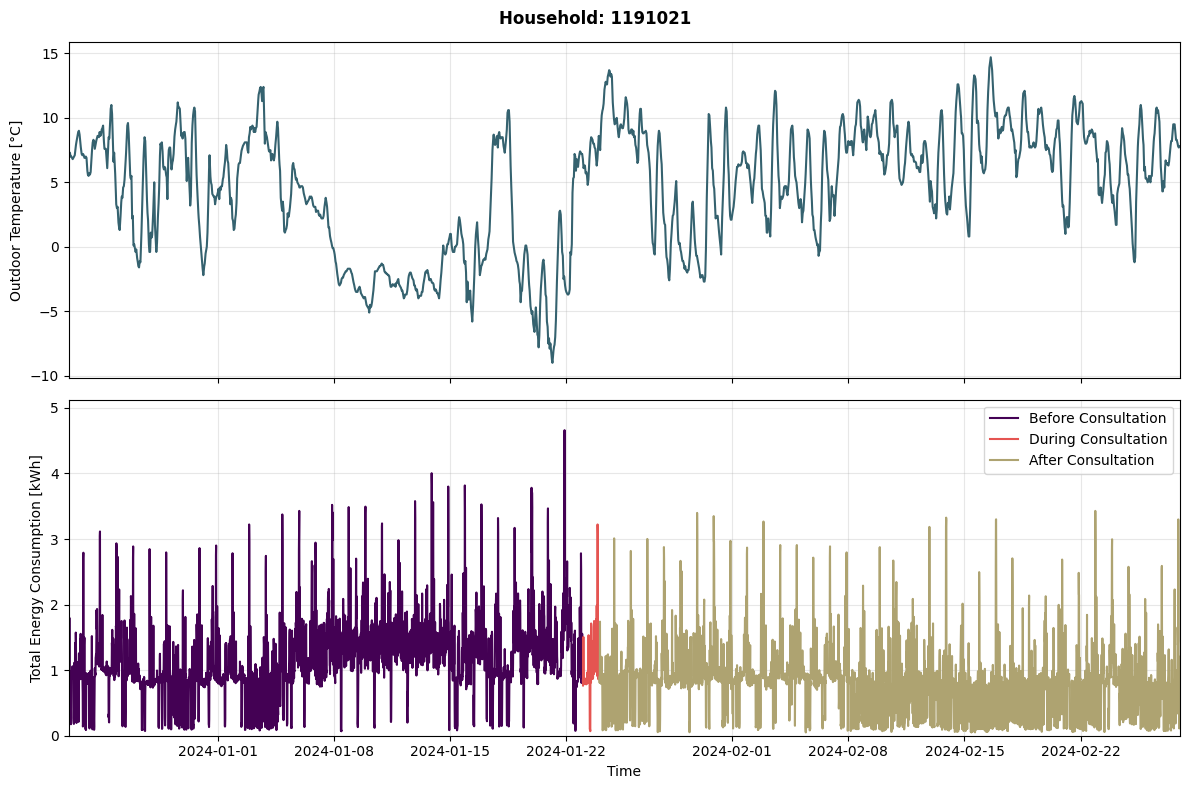

,Household_ID,Group,AffectsTimePoint,Timestamp,kWh_received_Total,kWh_received_HeatPump,kWh_received_Other,Temperature_avg_hourly,Temperature_max_daily,Temperature_min_daily,...,Spring,Summer,Autumn,TransitionPeriod,Cyclic_TimeOfDay_X,Cyclic_TimeOfDay_Y,Cyclic_DayOfYear_X,Cyclic_DayOfYear_Y,Cyclic_DayOfWeek_X,Cyclic_DayOfWeek_Y
32256,1191021,treatment,before visit,2023-12-23 00:00:00+00:00,0.842,NaN,NaN,7.400,9.1,6.6,...,False,False,False,False,0.000000,1.000000,-0.137279,0.990532,-0.974928,-0.222521
32257,1191021,treatment,before visit,2023-12-23 00:15:00+00:00,0.917,NaN,NaN,7.375,9.1,6.6,...,False,False,False,False,0.065403,0.997859,-0.137279,0.990532,-0.974928,-0.222521
32258,1191021,treatment,before visit,2023-12-23 00:30:00+00:00,0.883,NaN,NaN,7.350,9.1,6.6,...,False,False,False,False,0.130526,0.991445,-0.137279,0.990532,-0.974928,-0.222521
32259,1191021,treatment,before visit,2023-12-23 00:45:00+00:00,0.886,NaN,NaN,7.325,9.1,6.6,...,False,False,False,False,0.195090,0.980785,-0.137279,0.990532,-0.974928,-0.222521
32260,1191021,treatment,before visit,2023-12-23 01:00:00+00:00,0.859,NaN,NaN,7.300,9.1,6.6,...,False,False,False,False,0.258819,0.965926,-0.137279,0.990532,-0.974928,-0.222521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38683,1191021,treatment,after visit,2024-02-27 22:45:00+00:00,0.113,NaN,NaN,7.775,10.0,3.2,...,False,False,False,False,-0.321439,0.946930,0.840618,0.541628,0.781831,0.623490
38684,1191021,treatment,after visit,2024-02-27 23:00:00+00:00,1.204,NaN,NaN,7.800,10.0,3.2,...,False,False,False,False,-0.258819,0.965926,0.840618,0.541628,0.781831,0.623490
38685,1191021,treatment,after visit,2024-02-27 23:15:00+00:00,0.115,NaN,NaN,NaN,10.0,3.2,...,False,False,False,False,-0.195090,0.980785,0.840618,0.541628,0.781831,0.623490
38686,1191021,treatment,after visit,2024-02-27 23:30:00+00:00,0.175,NaN,NaN,NaN,10.0,3.2,...,False,False,False,False,-0.130526,0.991445,0.840618,0.541628,0.781831,0.623490


In [ ]:
household_id = 1191021

fig = plt.figure(figsize=(15, 5))

df = heapo.load_smart_meter_and_weather_data_combined(household_id, smd_resolution='15min', weather_resolution='hourly_and_daily', interpolate_hourly=True)
df = heapo.add_temporal_information(df, inplace=True)

df_protocol = heapo.load_protocol_data(household_id)

# limit time series around report date 
report_date = df_protocol['Visit_Date'].iloc[0]
df = heapo.limit_time_series_around_date(df, report_date, months_before=1, months_after=1, inplace=True)

# split into before and after report date
df_before, df_during, df_after = heapo.split_time_series_around_consultation(df)

# --------------------------------
# EXAMPLE: PLOT ENERGY CONSUMPTION
# --------------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Household: {}'.format(household_id), fontweight='bold')

# plot temperature 
ax = axes[0]
ax.plot(df['Timestamp'].values, df['Temperature_avg_hourly'].values, color=COLOR_DARK)
ax.set_ylabel('Outdoor Temperature [°C]')
ax.grid(alpha=0.3)

# plot energy consumption
ax = axes[1]
if len(df_before) > 0:
    ax.plot(df_before['Timestamp'].values, df_before['kWh_received_Total'].values, color=COLOR_PURPLE, label='Before Consultation')
if len(df_during) > 0:
    ax.plot(df_during['Timestamp'].values, df_during['kWh_received_Total'].values, color=COLOR_RED, label='During Consultation')
if len(df_after) > 0:
    ax.plot(df_after['Timestamp'].values, df_after['kWh_received_Total'].values, color=COLOR_YELLOW, label='After Consultation')
ax.set_xlabel('Time')
ax.set_ylabel('Total Energy Consumption [kWh]')
ax.set_xlim(df_before['Timestamp'].min(), df_after['Timestamp'].max())
ax.set_ylim(0, df['kWh_received_Total'].max() * 1.1)
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

display(df)

Text(0, 0.5, 'Daily Total Energy Consumption [kWh]')

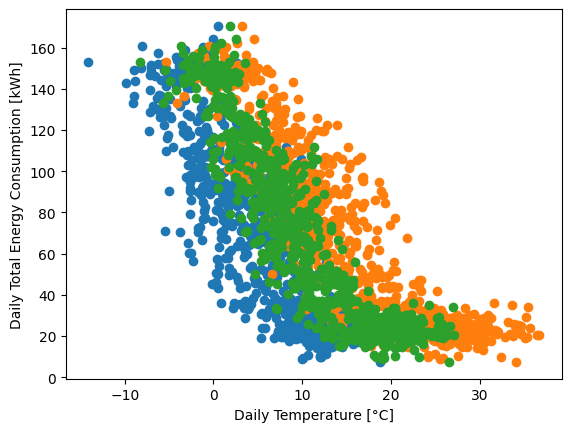

In [21]:
df2 = heapo.load_smart_meter_and_weather_data_combined(household_id, smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)

plt.scatter(df2['Temperature_min_daily'], df2['kWh_received_Total'])
plt.scatter(df2['Temperature_max_daily'], df2['kWh_received_Total'])
plt.scatter(df2['Temperature_avg_daily'], df2['kWh_received_Total'])
plt.xlabel('Daily Temperature [°C]')
plt.ylabel('Daily Total Energy Consumption [kWh]')

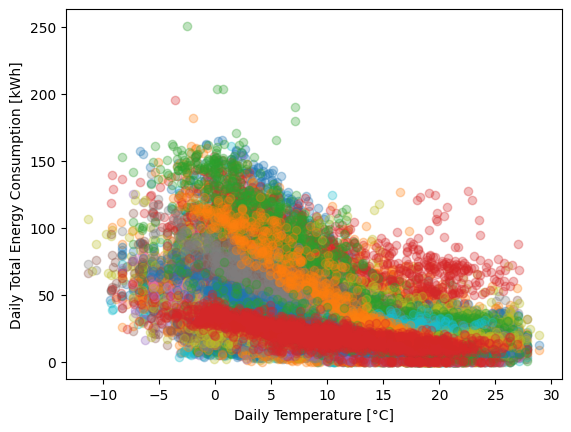

In [ ]:
df_meta = heapo.get_meta_data_overview()
df_meta = df_meta[df_meta['SmartMeterData_Available_Daily'] == True]

df_features = df_features[df_features['Household_ID'].isin(df_meta['Household_ID'])]

df_features.sort_values('HeatPump_Installation_HeatingCapacity', ascending=False, inplace=True)

for _,row in df_features.iterrows():
    household_id = row['Household_ID']
    df_house = heapo.load_smart_meter_and_weather_data_combined(household_id, smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)
    plt.scatter(df_house['Temperature_avg_daily'], df_house['kWh_received_Total'], alpha=0.3)
    plt.xlabel('Daily Temperature [°C]')
    plt.ylabel('Daily Total Energy Consumption [kWh]')
plt.show()

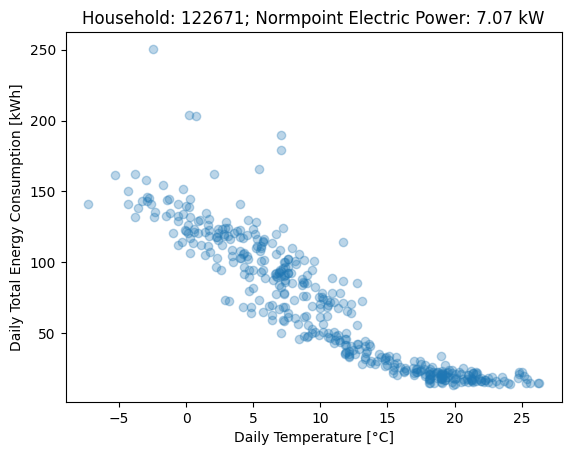

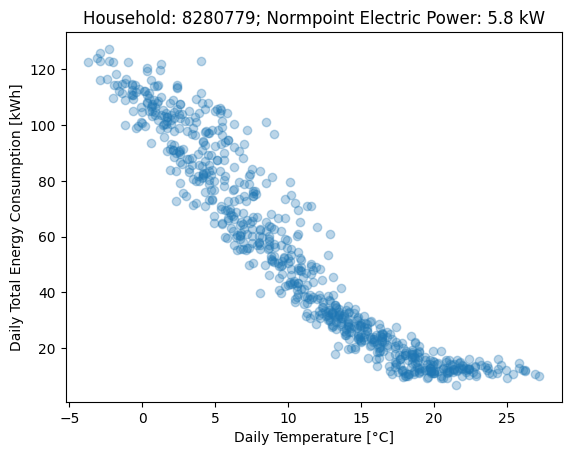

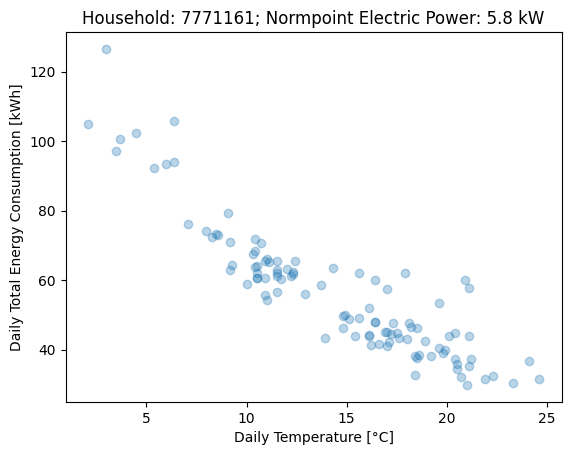

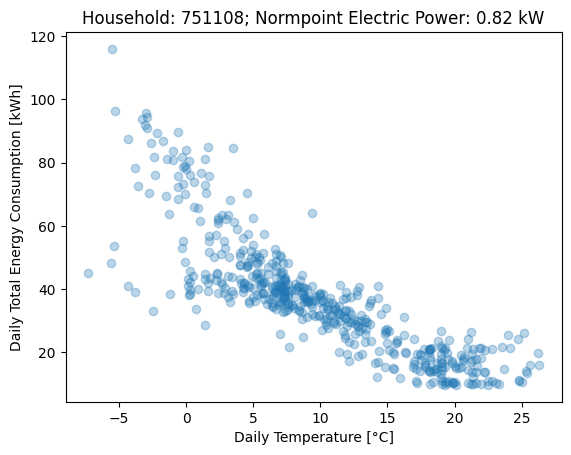

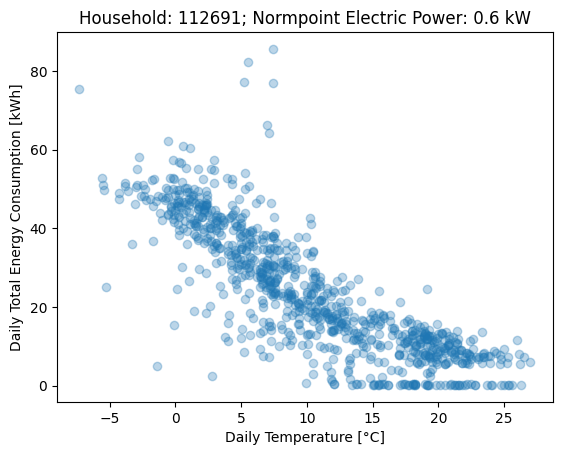

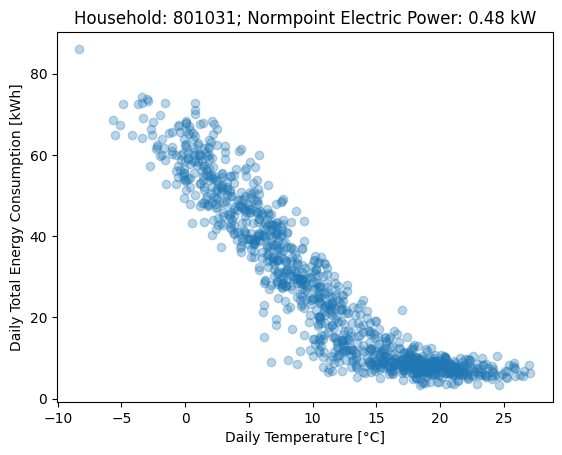

In [34]:
df_features.sort_values('HeatPump_Installation_Normpoint_ElectricPower', ascending=False, inplace=True)
df_features.dropna(subset=['HeatPump_Installation_Normpoint_ElectricPower'], inplace=True)

households_test = [df_features['Household_ID'].iloc[0], df_features['Household_ID'].iloc[1], df_features['Household_ID'].iloc[2], df_features['Household_ID'].iloc[-3], df_features['Household_ID'].iloc[-2], df_features['Household_ID'].iloc[-1]]

for household_id in households_test:
    df_house = heapo.load_smart_meter_and_weather_data_combined(household_id, smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)
    plt.scatter(df_house['Temperature_avg_daily'], df_house['kWh_received_Total'], alpha=0.3)
    plt.xlabel('Daily Temperature [°C]')
    plt.ylabel('Daily Total Energy Consumption [kWh]')
    plt.title('Household: {}; Normpoint Electric Power: {} kW'.format(household_id, df_features.loc[df_features['Household_ID'] == household_id, 'HeatPump_Installation_Normpoint_ElectricPower'].values[0]))
    plt.show()
